In [1]:
import numpy as np
import random
import cv2
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
# If running on colab
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)
cvgi_path = '/content/drive/MyDrive/Research/CVGI-2025/'
os.chdir(cvgi_path)

Mounted at /content/drive


In [3]:
# extracts image name and checks if it is jpg or png  and returns image name
def extract_img_name(img_path):
    img_name = img_path.split("/")[-1]

    if not (img_name.endswith(".jpg") or img_name.endswith(".png")):
        print(f"{img_name} Error: \n only .png or .jpg supported")
        return

    return img_name

In [4]:
def save_to_folder(img,output_folder,img_name,tag):
    os.makedirs(output_folder, exist_ok=True)
    name, ext = os.path.splitext(img_name)
    save_path = os.path.join(output_folder, f"{name}_{tag}{ext}")
    success = cv2.imwrite(save_path, img)

    if not success:
        print(f"Failed to save {save_path}")
        return

    print(f"{img_name} successfully {tag} !\n")
    return f" saved on {save_path}"



In [5]:
def show_images(img1, img2, title1="Image 1", title2="Image 2"):
    # Load if img1/img2 are paths
    if isinstance(img1, str):
        img1 = cv2.imread(img1)
    if isinstance(img2, str):
        img2 = cv2.imread(img2)

    # Convert BGR to RGB for matplotlib
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img1_rgb)
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img2_rgb)
    plt.title(title2)
    plt.axis('off')

    plt.show()


## Experiments
Run experiments on the transformed images using the CLIP model.

In [6]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-zwtgrtyb
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-zwtgrtyb
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b69093a137079b4e24d22f1e6ca4034442a5caee946c84bbc051ca9ee8833117
  Stored in directory: /tmp/pip-ephem-wheel-cache-iguc5_9n/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## Relative Alignment Drop (RAD) & Flip Rate
Calculate the Relative Alignment Drop (RAD) and the percentage of images where similarity drops after blurring for the original and blurred image pairs. Then, visualize the distributions of original and blurred similarities using histograms, and display the calculated average RAD and Drop Rate.

In [7]:
import json
import torch
import clip
# load CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def compute_similarity(image_path, text_prompt_or_json_path):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    if os.path.exists(text_prompt_or_json_path):
        # Assuming it's a JSON file path for captions
        with open(text_prompt_or_json_path, 'r') as f:
            captions_data = json.load(f)

        captions = [item for item in captions_data["captions"]]

        if not captions:
            return 0.0 # Return 0 if no captions are found

        all_caption_similarities = []
        for caption in captions:
            text_tokens = clip.tokenize([caption]).to(device)
            with torch.no_grad():
                image_features = model.encode_image(image)
                text_features = model.encode_text(text_tokens)
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)
                similarity = (image_features @ text_features.T).item()
                all_caption_similarities.append(similarity)

        return np.mean(all_caption_similarities)

    else:
        # Assuming it's a direct text prompt
        text_tokens = clip.tokenize([text_prompt_or_json_path]).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text_tokens)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            similarity = (image_features @ text_features.T).item()
        return similarity

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 110MiB/s]


In [19]:
## Setup Paths
input_folder = "COCO_100/images/"
captions_folder = "COCO_100/captions/"
images_folder = "images/"

cropped_output_folder     = "images/cropped/"
blurred_output_folder     = "images/blurred/"
grayscale_output_folder   = "images/grayscale/"
hue_shifted_output_folder = "images/hue_shifted/"
saturated_output_folder   = "images/saturated/"
bright_output_folder      = "images/bright/"
contrasted_output_folder  = "images/contrasted/"
sharpened_output_folder    = "images/sharpened/"
sobel_edges_output_folder = "images/sobel_edges/"

In [12]:
## Helper Functions
def setup_images_paths(input_folder, output_folder, transformation):
  """
  Sets up paths for original and transformed images.

  """
  original_image_paths = []
  transformed_image_paths = []

  for img_name in os.listdir(input_folder):
      original_path = os.path.join(input_folder, img_name)

      # Determine base name and extension
      basename, ext = os.path.splitext(img_name)

      # Construct transformed image name
      trans_img_name = f"{basename}_{transformation}{ext}"

      # Construct full path to the transformed image
      trans_path = os.path.join(output_folder, trans_img_name)

      # Check if both original and trans paths exist
      if os.path.exists(original_path) and os.path.exists(trans_path):
          original_image_paths.append(original_path)
          transformed_image_paths.append(trans_path)

  print(f"Found {len(original_image_paths)} pairs of original and {transformation} images.")
  return original_image_paths, transformed_image_paths

def calculate_similarities(original_image_paths, transformed_image_paths, captions_folder, transformation, compute_org_sim=True):
  original_similarities = []
  transformed_similarities = []

  for original_path, transformed_path in zip(original_image_paths, transformed_image_paths):
      # Extract the base name (without extension) from the original image path
      base_name = os.path.splitext(os.path.basename(original_path))[0]
      # Construct the path to the corresponding JSON file in the captions folder
      json_path = os.path.join(captions_folder, f"{base_name}.json")
      if not os.path.exists(json_path):
          print(f"Warning: JSON file not found for {original_path}. Skipping.")
          continue
      if compute_org_sim:
        original_sim = compute_similarity(original_path, json_path)
        original_similarities.append(original_sim)
      transformed_sim = compute_similarity(transformed_path, json_path)
      transformed_similarities.append(transformed_sim)

  print(f"Calculated {len(original_similarities)} original image similarities using captions.")
  print(f"Calculated {len(transformed_similarities)} {transformation} image similarities using captions.")

  return original_similarities, transformed_similarities

def calc_rad_and_drop_rate(original_similarities, transformed_similarities):
  rad_values = []
  for original_sim, transformed_sim in zip(original_similarities, transformed_similarities):
      if original_sim != 0: # Avoid division by zero
          rad = (original_sim - transformed_sim) / original_sim
          rad_values.append(rad)
      else:
          # Handle cases where original_sim is 0, perhaps append 0 or a specific value
          rad_values.append(0) # or np.nan, depending on how these cases should be treated

  # Calculate average RAD
  average_rad = np.mean(rad_values)

  # Calculate drop rate
  drop_count = 0
  for original_sim, transformed_sim in zip(original_similarities, transformed_similarities):
      if transformed_sim < original_sim:
          drop_count += 1

  total_number_of_images = len(original_similarities)
  drop_rate = (drop_count / total_number_of_images) * 100

  print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
  print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

  return average_rad, drop_rate

### Blurring

In [10]:
original_image_paths, blurred_image_paths = setup_images_paths(input_folder, blurred_output_folder, "blurred")
original_similarities, blurred_similarities = calculate_similarities(original_image_paths, blurred_image_paths, captions_folder, "blurred")
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, blurred_similarities)

Found 100 pairs of original and blurred images.
Calculated 100 original image similarities using captions.
Calculated 100 blurred image similarities using captions.
Average Relative Alignment Drop (RAD): 0.0099
Drop Rate (percentage of images where similarity drops): 65.00%


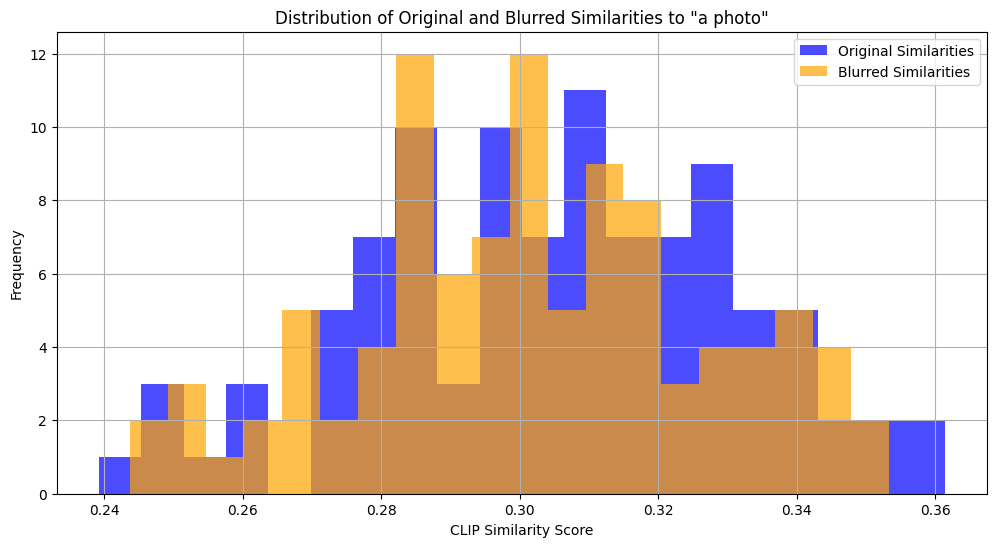

Average Relative Alignment Drop (RAD): 0.0099
Drop Rate (percentage of images where similarity drops): 65.00%


In [11]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(blurred_similarities, bins=20, alpha=0.7, label='Blurred Similarities', color='orange')

plt.title('Distribution of Original and Blurred Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Brightness

In [16]:
original_image_paths, bright_image_paths = setup_images_paths(input_folder, bright_output_folder, "brightened")
print(original_image_paths)
print(bright_image_paths)

Found 100 pairs of original and brightened images.
['COCO_100/images/000000436617.jpg', 'COCO_100/images/000000444275.jpg', 'COCO_100/images/000000455157.jpg', 'COCO_100/images/000000014473.jpg', 'COCO_100/images/000000543528.jpg', 'COCO_100/images/000000186637.jpg', 'COCO_100/images/000000454067.jpg', 'COCO_100/images/000000297085.jpg', 'COCO_100/images/000000419408.jpg', 'COCO_100/images/000000050943.jpg', 'COCO_100/images/000000474170.jpg', 'COCO_100/images/000000562229.jpg', 'COCO_100/images/000000011149.jpg', 'COCO_100/images/000000038576.jpg', 'COCO_100/images/000000526706.jpg', 'COCO_100/images/000000283318.jpg', 'COCO_100/images/000000465430.jpg', 'COCO_100/images/000000479448.jpg', 'COCO_100/images/000000092124.jpg', 'COCO_100/images/000000212800.jpg', 'COCO_100/images/000000292236.jpg', 'COCO_100/images/000000469174.jpg', 'COCO_100/images/000000081394.jpg', 'COCO_100/images/000000093353.jpg', 'COCO_100/images/000000172396.jpg', 'COCO_100/images/000000105923.jpg', 'COCO_100/im

In [18]:
original_image_paths, bright_image_paths = setup_images_paths(input_folder, bright_output_folder, "brightened")
# original_similarities, bright_similarities = calculate_similarities(original_image_paths, bright_image_paths, captions_folder, "bright")
_, bright_similarities = calculate_similarities(original_image_paths, bright_image_paths, captions_folder, "bright", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, bright_similarities)

Found 100 pairs of original and brightened images.
Calculated 100 original image similarities using captions.
Calculated 100 bright image similarities using captions.
Average Relative Alignment Drop (RAD): -0.0028
Drop Rate (percentage of images where similarity drops): 40.00%


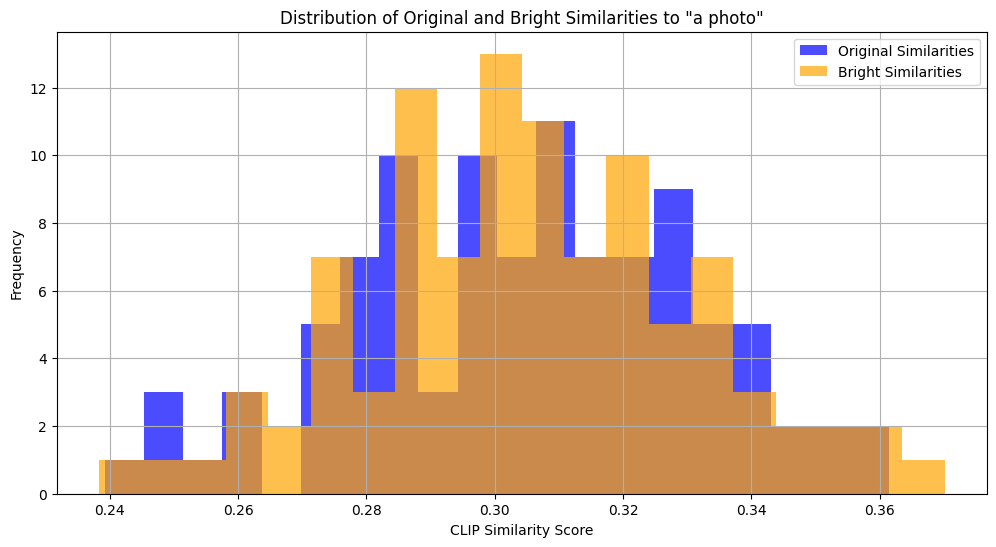

Average Relative Alignment Drop (RAD): -0.0028
Drop Rate (percentage of images where similarity drops): 40.00%


In [20]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(bright_similarities, bins=20, alpha=0.7, label='Bright Similarities', color='orange')

plt.title('Distribution of Original and Bright Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Contrast

In [21]:
original_image_paths, contrasted_image_paths = setup_images_paths(input_folder, contrasted_output_folder, "contrasted")
#original_similarities, contrasted_similarities = calculate_similarities(original_image_paths, contrasted_image_paths, captions_folder, "contrasted")
_, contrasted_similarities = calculate_similarities(original_image_paths, contrasted_image_paths, captions_folder, "contrasted", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, contrasted_similarities)

Found 100 pairs of original and contrasted images.
Calculated 0 original image similarities using captions.
Calculated 100 contrasted image similarities using captions.
Average Relative Alignment Drop (RAD): -0.0044
Drop Rate (percentage of images where similarity drops): 46.00%


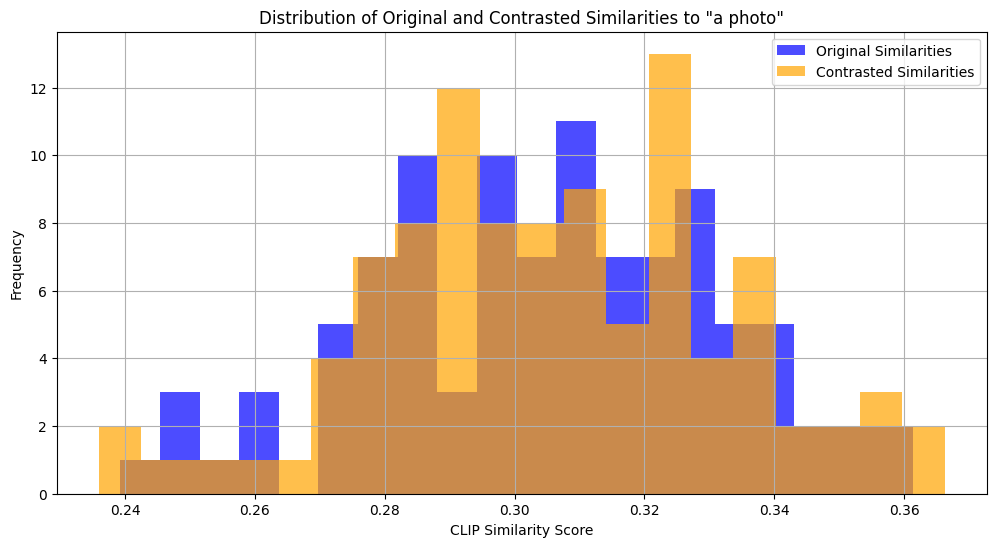

Average Relative Alignment Drop (RAD): -0.0044
Drop Rate (percentage of images where similarity drops): 46.00%


In [22]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(contrasted_similarities, bins=20, alpha=0.7, label='Contrasted Similarities', color='orange')

plt.title('Distribution of Original and Contrasted Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Cropping

In [23]:
original_image_paths, cropped_image_paths = setup_images_paths(input_folder, cropped_output_folder, "cropped")
# original_similarities, cropped_similarities = calculate_similarities(original_image_paths, cropped_image_paths, captions_folder, "cropped")
_, cropped_similarities = calculate_similarities(original_image_paths, cropped_image_paths, captions_folder, "cropped", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, cropped_similarities)

Found 100 pairs of original and cropped images.
Calculated 0 original image similarities using captions.
Calculated 100 cropped image similarities using captions.
Average Relative Alignment Drop (RAD): 0.0046
Drop Rate (percentage of images where similarity drops): 54.00%


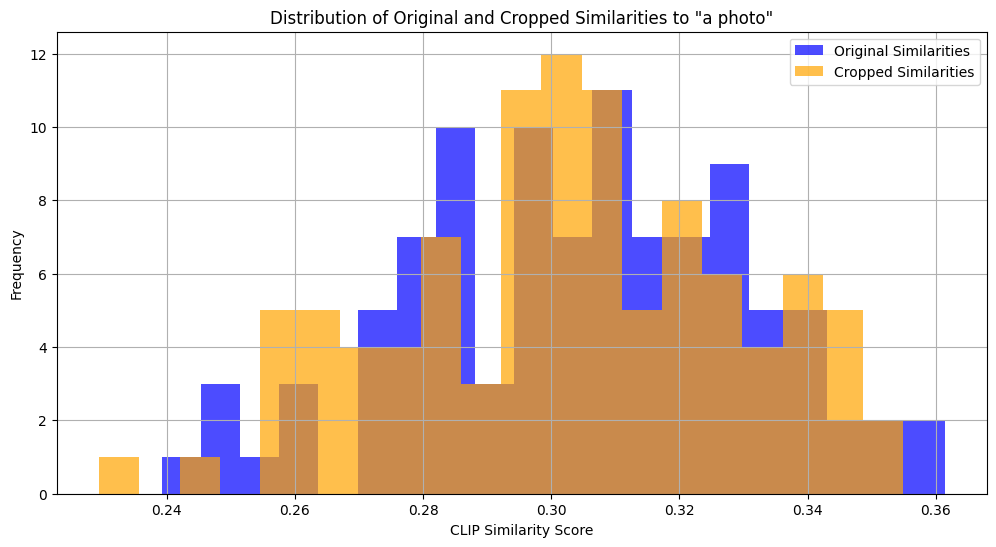

Average Relative Alignment Drop (RAD): 0.0046
Drop Rate (percentage of images where similarity drops): 54.00%


In [24]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(cropped_similarities, bins=20, alpha=0.7, label='Cropped Similarities', color='orange')

plt.title('Distribution of Original and Cropped Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Grayscale

In [25]:
original_image_paths, grayscale_image_paths = setup_images_paths(input_folder, grayscale_output_folder, "gray")
# original_similarities, grayscale_similarities = calculate_similarities(original_image_paths, grayscale_image_paths, captions_folder, "gray")
_ , grayscale_similarities = calculate_similarities(original_image_paths, grayscale_image_paths, captions_folder, "gray", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, grayscale_similarities)

Found 100 pairs of original and gray images.
Calculated 0 original image similarities using captions.
Calculated 100 gray image similarities using captions.
Average Relative Alignment Drop (RAD): 0.0285
Drop Rate (percentage of images where similarity drops): 71.00%


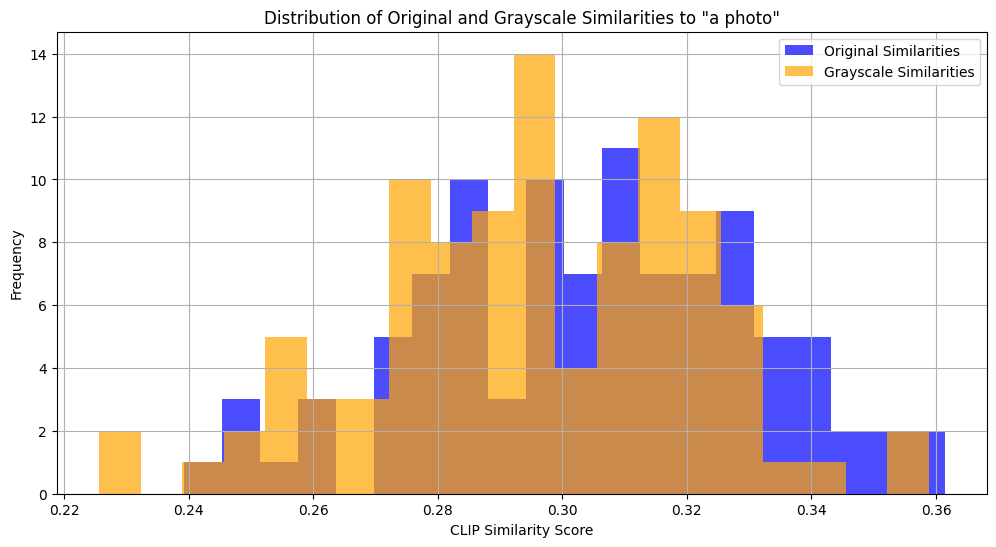

Average Relative Alignment Drop (RAD): 0.0285
Drop Rate (percentage of images where similarity drops): 71.00%


In [26]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(grayscale_similarities, bins=20, alpha=0.7, label='Grayscale Similarities', color='orange')

plt.title('Distribution of Original and Grayscale Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Hue Shifting

In [27]:
original_image_paths, hue_shifted_image_paths = setup_images_paths(input_folder, hue_shifted_output_folder, "hue")
# original_similarities, hue_shifted_similarities = calculate_similarities(original_image_paths, hue_shifted_image_paths, captions_folder, "hue")
_, hue_shifted_similarities = calculate_similarities(original_image_paths, hue_shifted_image_paths, captions_folder, "hue", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, hue_shifted_similarities)

Found 100 pairs of original and hue images.
Calculated 0 original image similarities using captions.
Calculated 100 hue image similarities using captions.
Average Relative Alignment Drop (RAD): 0.1006
Drop Rate (percentage of images where similarity drops): 86.00%


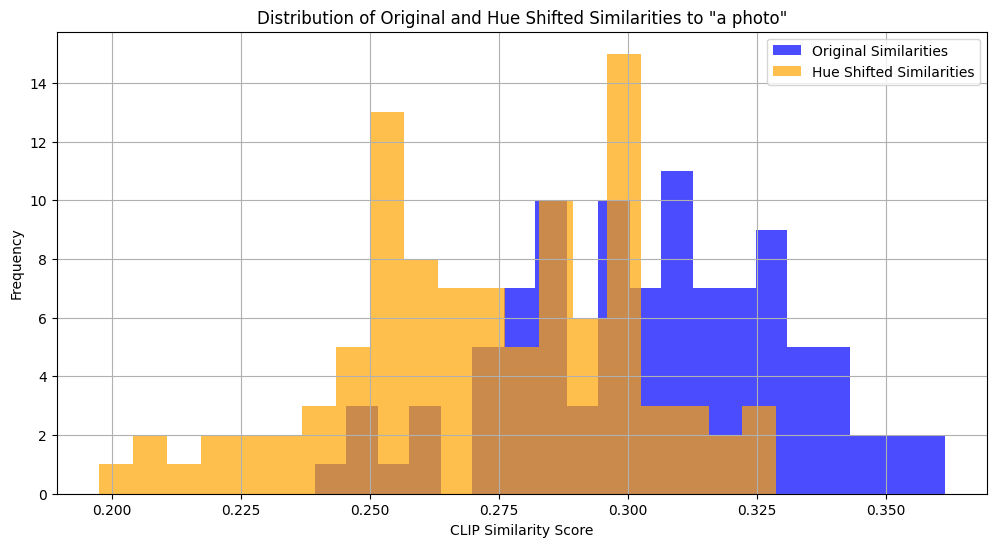

Average Relative Alignment Drop (RAD): 0.1006
Drop Rate (percentage of images where similarity drops): 86.00%


In [28]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(hue_shifted_similarities, bins=20, alpha=0.7, label='Hue Shifted Similarities', color='orange')

plt.title('Distribution of Original and Hue Shifted Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Saturation

In [29]:
original_image_paths, saturated_image_paths = setup_images_paths(input_folder, saturated_output_folder, "saturated")
# original_similarities, saturated_similarities = calculate_similarities(original_image_paths, saturated_image_paths, captions_folder, "saturated")
_, saturated_similarities = calculate_similarities(original_image_paths, saturated_image_paths, captions_folder, "saturated", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, saturated_similarities)

Found 100 pairs of original and saturated images.
Calculated 0 original image similarities using captions.
Calculated 100 saturated image similarities using captions.
Average Relative Alignment Drop (RAD): -0.0067
Drop Rate (percentage of images where similarity drops): 38.00%


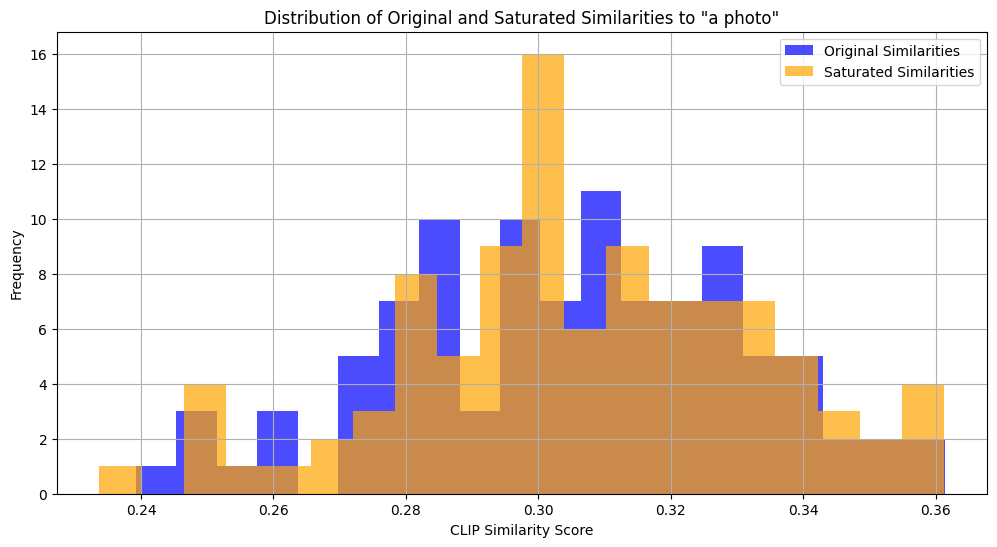

Average Relative Alignment Drop (RAD): -0.0067
Drop Rate (percentage of images where similarity drops): 38.00%


In [30]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(saturated_similarities, bins=20, alpha=0.7, label='Saturated Similarities', color='orange')

plt.title('Distribution of Original and Saturated Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Sharpening

In [31]:
original_image_paths, sharpened_image_paths = setup_images_paths(input_folder, sharpened_output_folder, "sharpened")
# original_similarities, sharpened_similarities = calculate_similarities(original_image_paths, sharpened_image_paths, captions_folder, "sharpened")
_, sharpened_similarities = calculate_similarities(original_image_paths, sharpened_image_paths, captions_folder, "sharpened", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, sharpened_similarities)

Found 100 pairs of original and sharpened images.
Calculated 0 original image similarities using captions.
Calculated 100 sharpened image similarities using captions.
Average Relative Alignment Drop (RAD): -0.0094
Drop Rate (percentage of images where similarity drops): 37.00%


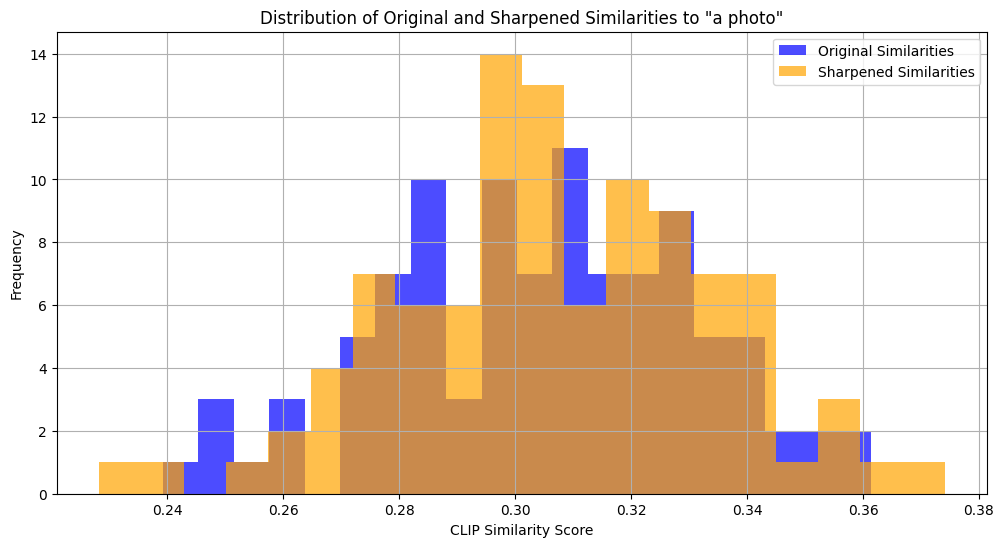

Average Relative Alignment Drop (RAD): -0.0094
Drop Rate (percentage of images where similarity drops): 37.00%


In [32]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(sharpened_similarities, bins=20, alpha=0.7, label='Sharpened Similarities', color='orange')

plt.title('Distribution of Original and Sharpened Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

### Edges

In [33]:
original_image_paths, sobel_edges_image_paths = setup_images_paths(input_folder, sobel_edges_output_folder, "sobel_edges")
# original_similarities, sobel_edges_similarities = calculate_similarities(original_image_paths, sobel_edges_image_paths, captions_folder, "sobel_edges")
_, sobel_edges_similarities = calculate_similarities(original_image_paths, sobel_edges_image_paths, captions_folder, "sobel_edges", compute_org_sim=False)
average_rad, drop_rate = calc_rad_and_drop_rate(original_similarities, sobel_edges_similarities)

Found 100 pairs of original and sobel_edges images.
Calculated 0 original image similarities using captions.
Calculated 100 sobel_edges image similarities using captions.
Average Relative Alignment Drop (RAD): 0.1665
Drop Rate (percentage of images where similarity drops): 94.00%


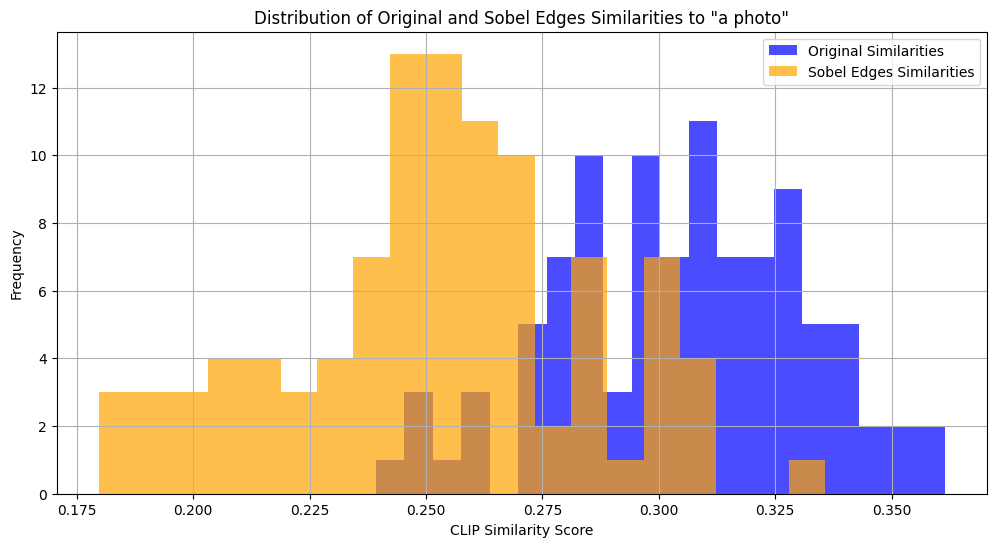

Average Relative Alignment Drop (RAD): 0.1665
Drop Rate (percentage of images where similarity drops): 94.00%


In [34]:
plt.figure(figsize=(12, 6))

plt.hist(original_similarities, bins=20, alpha=0.7, label='Original Similarities', color='blue')
plt.hist(sobel_edges_similarities, bins=20, alpha=0.7, label='Sobel Edges Similarities', color='orange')

plt.title('Distribution of Original and Sobel Edges Similarities to "a photo"')
plt.xlabel('CLIP Similarity Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Relative Alignment Drop (RAD): {average_rad:.4f}")
print(f"Drop Rate (percentage of images where similarity drops): {drop_rate:.2f}%")

## Analysis

# Task
Consolidate metrics for each image transformation (blurring, brightness, contrast, cropping, grayscale, hue shifting, saturation, sharpening, and Sobel edges), present them in a summary table, and then analyze and interpret these results to identify key insights and propose next steps for applying grounding strategies to address observed misalignments in CLIP's vision-language understanding.

In [35]:
import pandas as pd

# 1. Re-calculate RAD and Drop Rate for 'blurring'
blurred_average_rad, blurred_drop_rate = calc_rad_and_drop_rate(original_similarities, blurred_similarities)

# 2. Re-calculate RAD and Drop Rate for 'brightness'
bright_average_rad, bright_drop_rate = calc_rad_and_drop_rate(original_similarities, bright_similarities)

# 3. Re-calculate RAD and Drop Rate for 'contrast'
contrasted_average_rad, contrasted_drop_rate = calc_rad_and_drop_rate(original_similarities, contrasted_similarities)

# 4. Re-calculate RAD and Drop Rate for 'cropping'
cropped_average_rad, cropped_drop_rate = calc_rad_and_drop_rate(original_similarities, cropped_similarities)

# 5. Re-calculate RAD and Drop Rate for 'grayscale'
grayscale_average_rad, grayscale_drop_rate = calc_rad_and_drop_rate(original_similarities, grayscale_similarities)

# 6. Re-calculate RAD and Drop Rate for 'hue shifting'
hue_shifted_average_rad, hue_shifted_drop_rate = calc_rad_and_drop_rate(original_similarities, hue_shifted_similarities)

# 7. Re-calculate RAD and Drop Rate for 'saturation'
saturated_average_rad, saturated_drop_rate = calc_rad_and_drop_rate(original_similarities, saturated_similarities)

# 8. Re-calculate RAD and Drop Rate for 'sharpening'
sharpened_average_rad, sharpened_drop_rate = calc_rad_and_drop_rate(original_similarities, sharpened_similarities)

# 9. Re-calculate RAD and Drop Rate for 'Sobel edges'
sobel_edges_average_rad, sobel_edges_drop_rate = calc_rad_and_drop_rate(original_similarities, sobel_edges_similarities)

# 10. Create a dictionary named results_data
results_data = {
    "Blurring": {"Average RAD": blurred_average_rad, "Drop Rate": blurred_drop_rate},
    "Brightness": {"Average RAD": bright_average_rad, "Drop Rate": bright_drop_rate},
    "Contrast": {"Average RAD": contrasted_average_rad, "Drop Rate": contrasted_drop_rate},
    "Cropping": {"Average RAD": cropped_average_rad, "Drop Rate": cropped_drop_rate},
    "Grayscale": {"Average RAD": grayscale_average_rad, "Drop Rate": grayscale_drop_rate},
    "Hue Shifting": {"Average RAD": hue_shifted_average_rad, "Drop Rate": hue_shifted_drop_rate},
    "Saturation": {"Average RAD": saturated_average_rad, "Drop Rate": saturated_drop_rate},
    "Sharpening": {"Average RAD": sharpened_average_rad, "Drop Rate": sharpened_drop_rate},
    "Sobel Edges": {"Average RAD": sobel_edges_average_rad, "Drop Rate": sobel_edges_drop_rate}
}

metrics_df = pd.DataFrame.from_dict(results_data, orient='index')

print("Consolidated Metrics DataFrame:")
print(metrics_df)

Average Relative Alignment Drop (RAD): 0.0099
Drop Rate (percentage of images where similarity drops): 65.00%
Average Relative Alignment Drop (RAD): -0.0028
Drop Rate (percentage of images where similarity drops): 40.00%
Average Relative Alignment Drop (RAD): -0.0044
Drop Rate (percentage of images where similarity drops): 46.00%
Average Relative Alignment Drop (RAD): 0.0046
Drop Rate (percentage of images where similarity drops): 54.00%
Average Relative Alignment Drop (RAD): 0.0285
Drop Rate (percentage of images where similarity drops): 71.00%
Average Relative Alignment Drop (RAD): 0.1006
Drop Rate (percentage of images where similarity drops): 86.00%
Average Relative Alignment Drop (RAD): -0.0067
Drop Rate (percentage of images where similarity drops): 38.00%
Average Relative Alignment Drop (RAD): -0.0094
Drop Rate (percentage of images where similarity drops): 37.00%
Average Relative Alignment Drop (RAD): 0.1665
Drop Rate (percentage of images where similarity drops): 94.00%
Consol

## Analysis and Interpretation

**Consolidated Metrics:**
```
              Average RAD  Drop Rate
Blurring         0.009911       65.0
Brightness      -0.002827       40.0
Contrast        -0.004382       46.0
Cropping         0.004562       54.0
Grayscale        0.028495       71.0
Hue Shifting     0.100608       86.0
Saturation      -0.006731       38.0
Sharpening      -0.009414       37.0
Sobel Edges      0.166521       94.0
```

**Key Observations:**

1.  **Highest Alignment Drop (Positive RAD):**
    *   **Sobel Edges (RAD: 0.1665, Drop Rate: 94.00%)**: This transformation causes the most significant average drop in similarity and affects the highest percentage of images. This suggests that removing texture and retaining only edge information severely degrades CLIP's ability to align images with their captions.
    *   **Hue Shifting (RAD: 0.1006, Drop Rate: 86.00%)**: Altering the color hue also leads to a substantial alignment drop and a high drop rate, indicating CLIP's sensitivity to color information.
    *   **Grayscale (RAD: 0.0285, Drop Rate: 71.00%)**: Converting images to grayscale results in a notable drop, further emphasizing the importance of color for CLIP's understanding.

2.  **Moderate Alignment Drop:**
    *   **Blurring (RAD: 0.0099, Drop Rate: 65.00%)**: Blurring, while having a positive RAD (meaning similarity generally drops), has a relatively small average drop compared to edge detection or hue shifting. However, it still impacts a significant number of images (65%). This indicates that fine details might contribute to CLIP's performance, but overall scene understanding might be retained to some extent.
    *   **Cropping (RAD: 0.0046, Drop Rate: 54.00%)**: Cropping also shows a small positive RAD and a moderate drop rate. This suggests that while some context might be lost, the central content often remains recognizable by CLIP.

3.  **Improved/Slightly Reduced Alignment Drop (Negative RAD):**
    *   **Sharpening (RAD: -0.0094, Drop Rate: 37.00%)**: Sharpening actually leads to a slight *increase* in similarity on average (negative RAD). This could be because sharpening enhances visual features that CLIP relies on. It also has one of the lowest drop rates.
    *   **Saturation (RAD: -0.0067, Drop Rate: 38.00%)**: Similar to sharpening, saturation generally improves or maintains similarity, with a low drop rate.
    *   **Contrast (RAD: -0.0044, Drop Rate: 46.00%)**: Adjusting contrast also shows a slight average increase in similarity, though it affects more images with a drop than sharpening or saturation.
    *   **Brightness (RAD: -0.0028, Drop Rate: 40.00%)**: Brightness adjustments show a minimal average increase in similarity and a relatively low drop rate.